## # Exp. 3 | **ARIMA**
### GEC0319 | JIVB | Time Series
- Experiment N° **3**  
- Link: [here](https://ocw.mit.edu/courses/18-s096-topics-in-mathematics-with-applications-in-finance-fall-2013/1926c83ecd7ea700f7cb63914c6d7c0f_MIT18_S096F13_lecnote8.pdf)

## Settings

In [ ]:
pip install tswidgets

In [ ]:
from tswidgets import *
import pandas as pd
import numpy as np
np.random.seed(42)
from random import gauss
from pandas.plotting import autocorrelation_plot
import warnings
import itertools
from random import random




import statsmodels.formula.api as smf
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AR
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import matplotlib.pyplot as plt
from string import ascii_letters
import seaborn as sns


# general settings
class CFG:
    data_folder = '/data/'
    img_dim1 = 25
    img_dim2 = 8
    style = 'https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-light.mplstyle'


# adjust the parameters for displayed figures
plt.rcParams.update({'figure.figsize': (CFG.img_dim1,CFG.img_dim2)})
plt.style.use(CFG.style)


## Get Data

In [ ]:
df = sm.datasets.interest_inflation.load_pandas().data
df['ts'] = df['year'].astype(int).astype(str)+'_'+df['quarter'].astype(int).astype(str)
df.drop(columns=['year','quarter'],inplace=True)
df = df.set_index('ts')
df.head()

,Dp,R
ts,,
1972_2,-0.003133,0.083
1972_3,0.018871,0.083
1972_4,0.024804,0.087
1973_1,0.016278,0.087
1973_2,0.000290,0.102


In [ ]:
sun = sm.datasets.sunspots.load_pandas().data
sun['YEAR'] = pd.to_datetime(sun['YEAR'].astype(int), format='%Y')
sun = sun.set_index('YEAR')
sun.head()

,SUNACTIVITY
YEAR,
1700-01-01,5.0
1701-01-01,11.0
1702-01-01,16.0
1703-01-01,23.0
1704-01-01,36.0


## Box & Jenkings

#### Exploratory Data Analysis

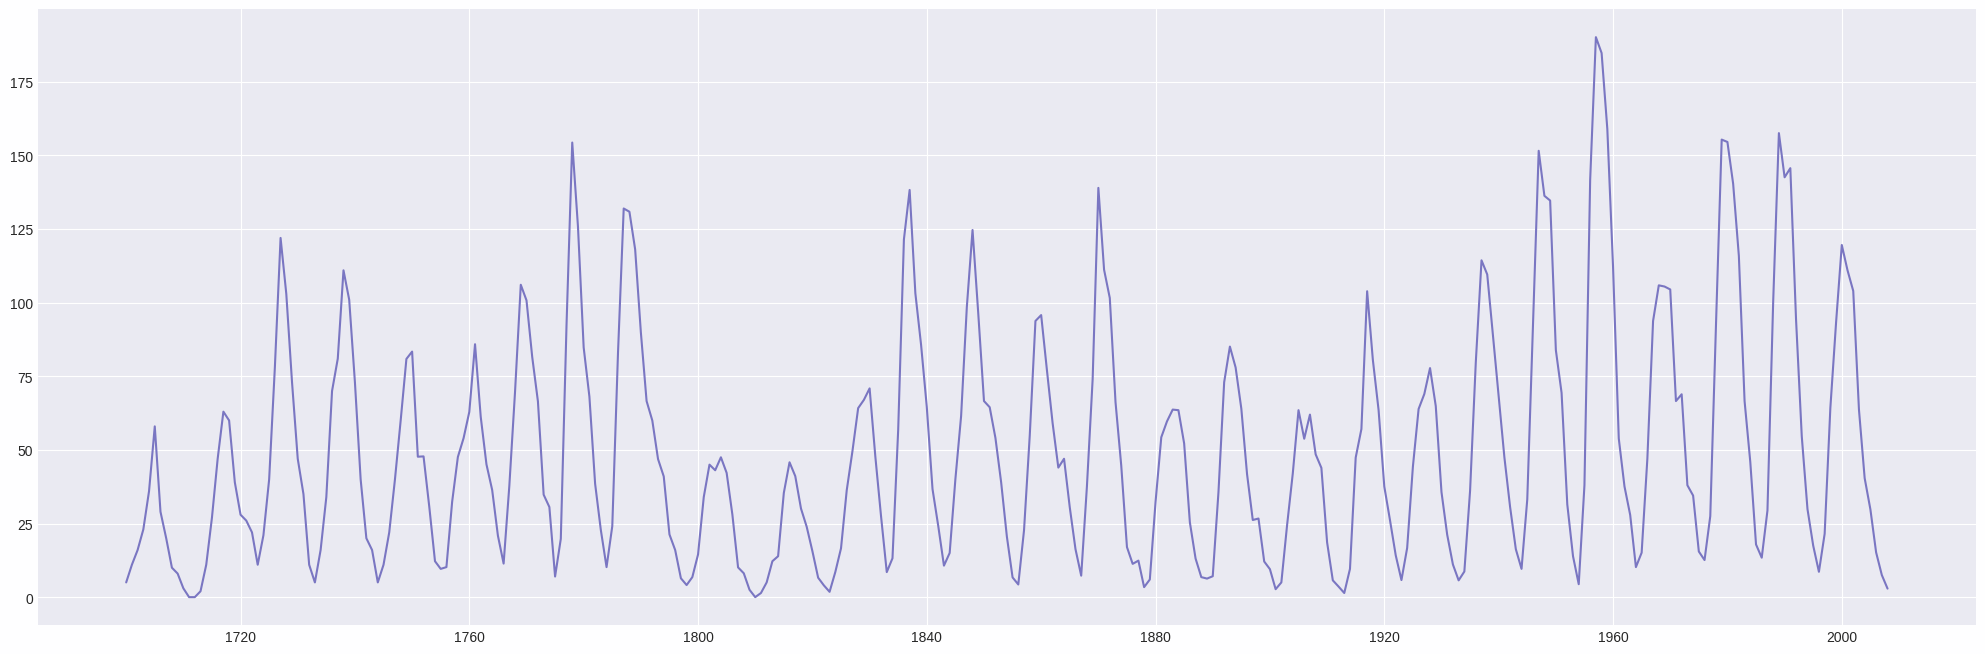

In [ ]:
plt.plot(sun);

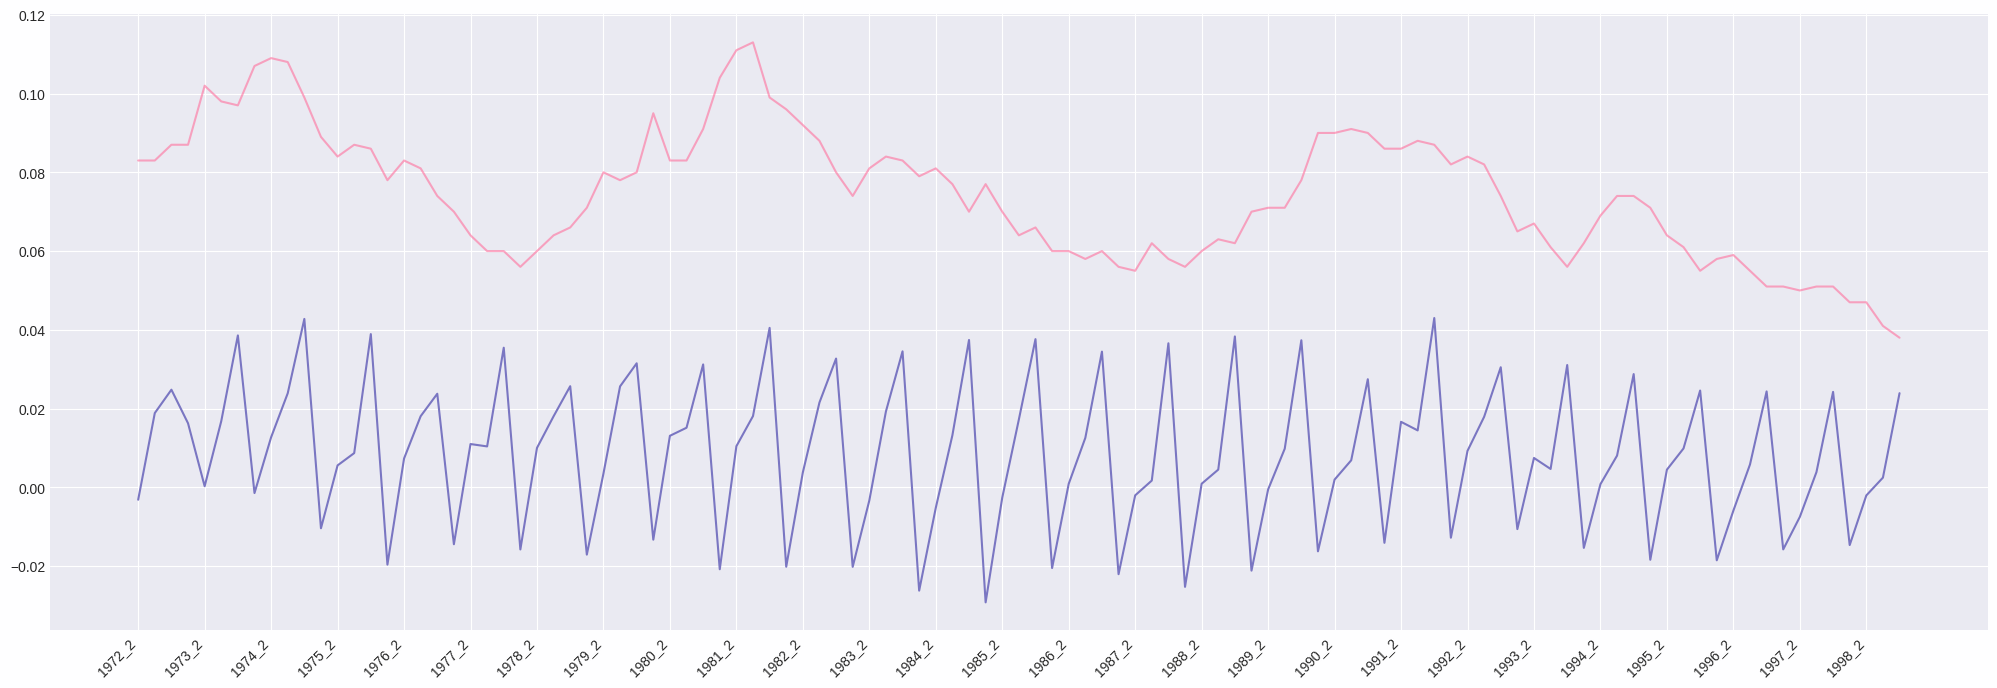

In [ ]:
plt.plot(df);
# plt.xticks(rotation=45, ha='right');

# Get the current x-tick locations and labels
ticks = plt.gca().get_xticks()
labels = plt.gca().get_xticklabels()

# Skip every 1 in 3 labels (keep every 3rd label)
plt.xticks(ticks[::4], labels[::4], rotation=45, ha='right');

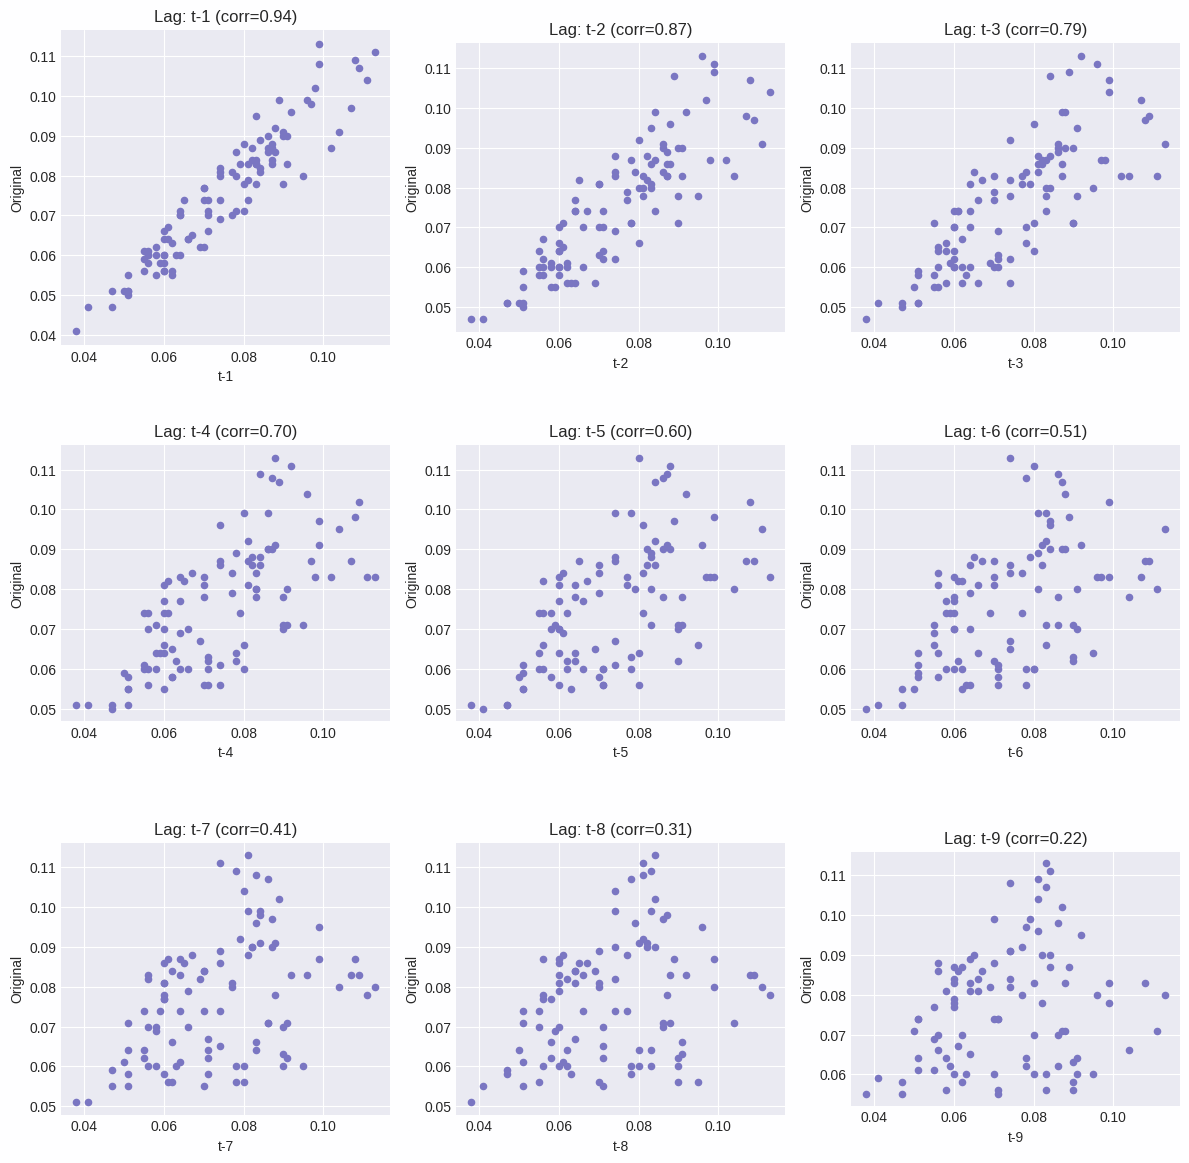

In [ ]:
def sdt_auto_scatter(series,lags=9,ncols=3):
    '''
    gráfico de scatterplot para los rezagos
    '''
    series = pd.Series(series)

    nrows=int(np.ceil(lags/ncols))
    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols, 4*nrows))
    for ax, lag in zip(axes.flat, np.arange(1,lags+1, 1)):
        lag_str = 't-{}'.format(lag)
        X = (pd.concat([series, series.shift(-lag)], axis=1,
                       keys=['y'] + [lag_str]).dropna())

        X.plot(ax=ax, kind='scatter', y='y', x=lag_str);
        corr = X.corr().to_numpy()[0][1]# X.corr().as_matrix()[0][1]
        ax.set_ylabel('Original')
        ax.set_title('Lag: {} (corr={:.2f})'.format(lag_str, corr));
        ax.set_aspect('equal');
        sns.despine();
    fig.tight_layout();
sdt_auto_scatter(df.R);

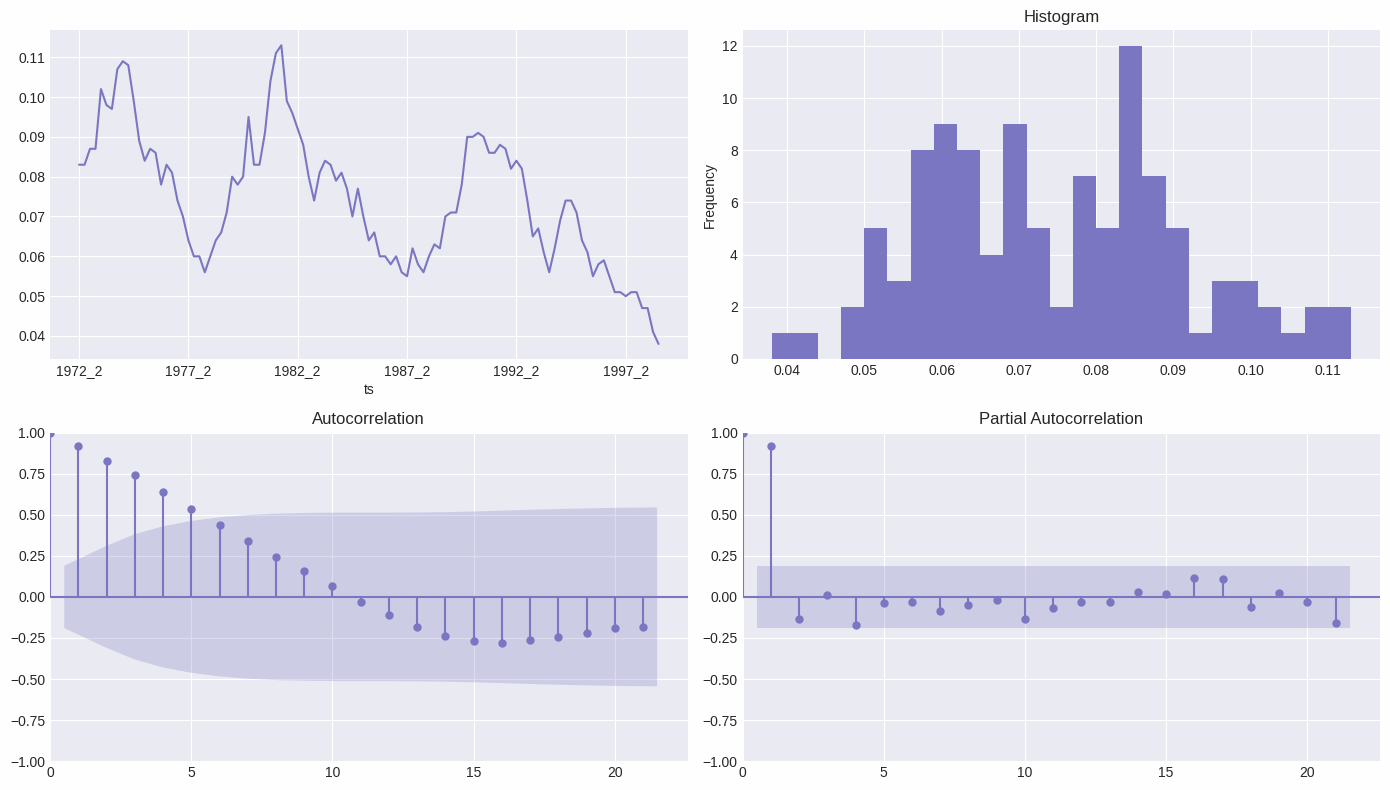

In [ ]:
def tsplot(y, lags=None, title='', figsize=(14, 8)):
    '''Examine the patterns of ACF and PACF, along with the time series plot and histogram.

    Original source: https://tomaugspurger.github.io/modern-7-timeseries.html
    '''
    fig = plt.figure(figsize=figsize)
    layout = (2, 2)
    ts_ax   = plt.subplot2grid(layout, (0, 0))
    hist_ax = plt.subplot2grid(layout, (0, 1))
    acf_ax  = plt.subplot2grid(layout, (1, 0))
    pacf_ax = plt.subplot2grid(layout, (1, 1))

    y.plot(ax=ts_ax)
    ts_ax.set_title(title)
    y.plot(ax=hist_ax, kind='hist', bins=25)
    hist_ax.set_title('Histogram')
    smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
    smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
    [ax.set_xlim(0) for ax in [acf_ax, pacf_ax]]
    sns.despine()
    plt.tight_layout()
    return ts_ax, acf_ax, pacf_ax
tsplot(df.R);

In [ ]:
def sdt_compare(serie):
    '''
    compara los momentos de la distribución partinedo la serie en 2
    '''
    split =  int(len(serie) / 2)
    X1, X2 = serie[0:split], serie[split:]
    mean1, mean2 = np.round(X1.mean(),0), np.round(X2.mean(),0)
    std1, std2 = np.round(X1.std(),0), np.round(X2.std(),0)
    print(f'media A:{mean1} - media B:{mean2} - ratio A/B = {np.round(100*mean1/mean2,2)}%')
    print(f'desvest A : {std1} - desvest B: {std2}  - ratio A/B = {np.round(100*std1/std2,2)}%')
    return [mean1,mean2,std1,std2]
_ = sdt_compare(df.R);

media A:0.0 - media B:0.0 - ratio A/B = nan%
desvest A : 0.0 - desvest B: 0.0  - ratio A/B = nan%


<ipython-input-9-ce1a78570527>:9: RuntimeWarning: invalid value encountered in scalar divide
  print(f'media A:{mean1} - media B:{mean2} - ratio A/B = {np.round(100*mean1/mean2,2)}%')
<ipython-input-9-ce1a78570527>:10: RuntimeWarning: invalid value encountered in scalar divide
  print(f'desvest A : {std1} - desvest B: {std2}  - ratio A/B = {np.round(100*std1/std2,2)}%')


### Fitting

#### Predefined Parameters

In [ ]:
# Fit the model
arima100 = sm.tsa.SARIMAX(df.R, order=(1,0,0))
model_results = arima100.fit();
model_results.summary()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      R   No. Observations:                  107
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 401.844
Date:                Thu, 12 Sep 2024   AIC                           -799.689
Time:                        12:07:40   BIC                           -794.343
Sample:                             0   HQIC                          -797.522
                                - 107                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9930      0.005    202.741      0.000       0.983       1.003
sigma2      3.077e-05   4.11e-06      7.485      0.000    2.27e-05    3.88e-05
===================================================================================
Ljung-Box (L1) (Q):                   2.63   Jarque-Bera (JB):                 3.94
Prob(Q):                              0.10   Prob(JB):                         0.14
Heteroskedasticity (H):               0.42   Skew:                             0.45
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.24
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
def get_diff(X, n=1):
    diffs = np.diff(X, n=n)
    return np.concatenate([ np.full(n, np.nan), diffs])
df['delta_R'] = get_diff(df.R)
df.head(4)

,Dp,R,delta_R
ts,,,
1972_2,-0.003133,0.083,NaN
1972_3,0.018871,0.083,0.000
1972_4,0.024804,0.087,0.004
1973_1,0.016278,0.087,0.000


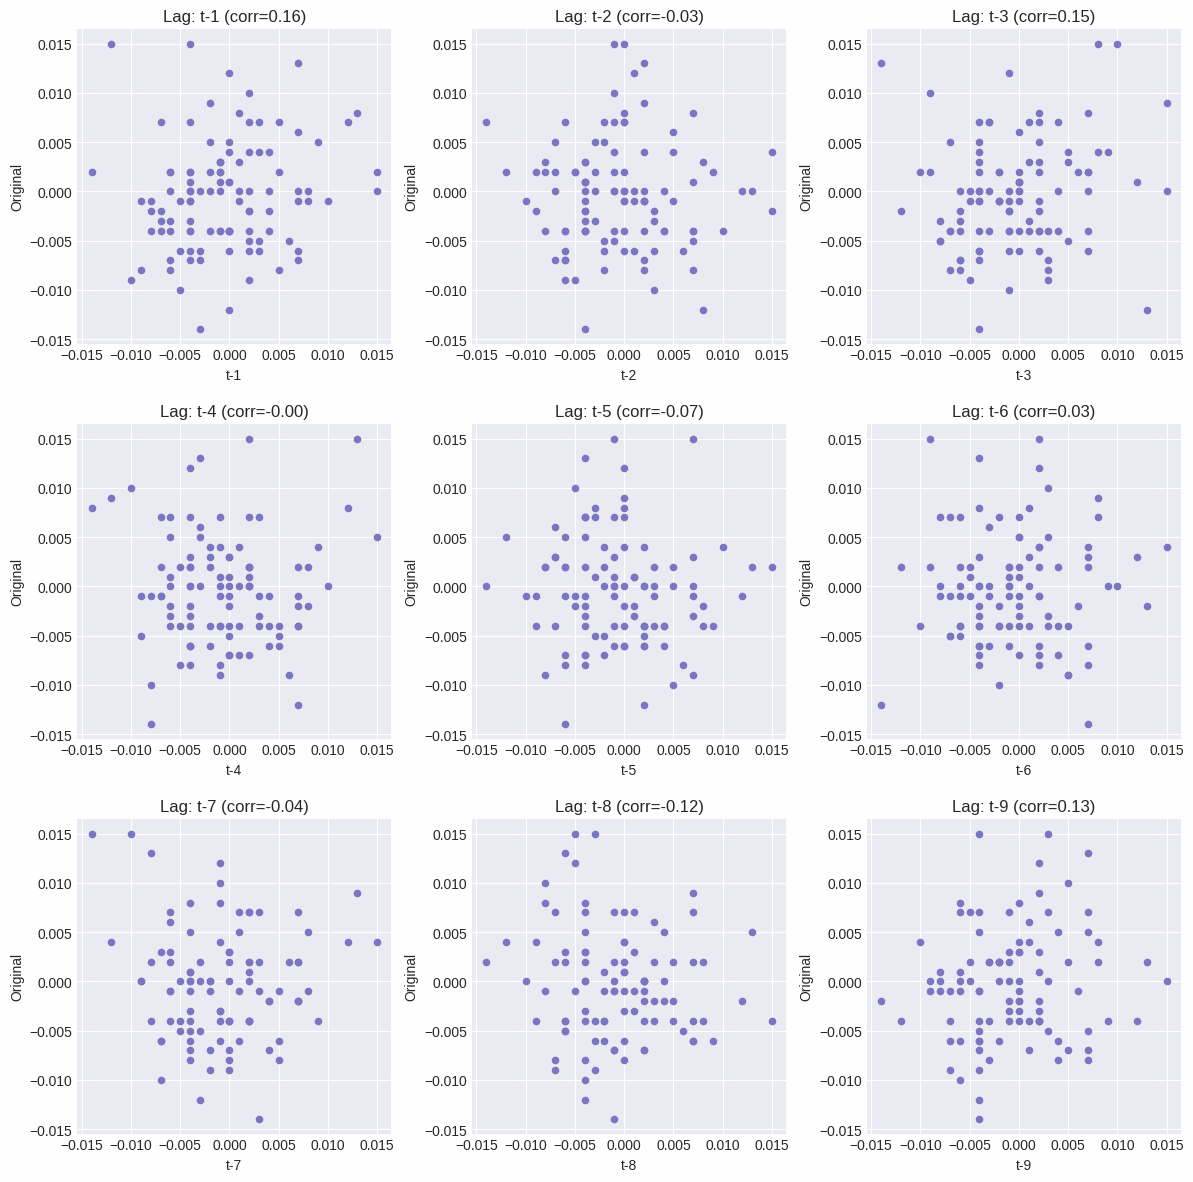

In [ ]:
sdt_auto_scatter(df.delta_R)

/usr/local/lib/python3.10/dist-packages/matplotlib/axes/_base.py:2503: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


(<Axes: xlabel='ts'>,
 <Axes: title={'center': 'Autocorrelation'}>,
 <Axes: title={'center': 'Partial Autocorrelation'}>)

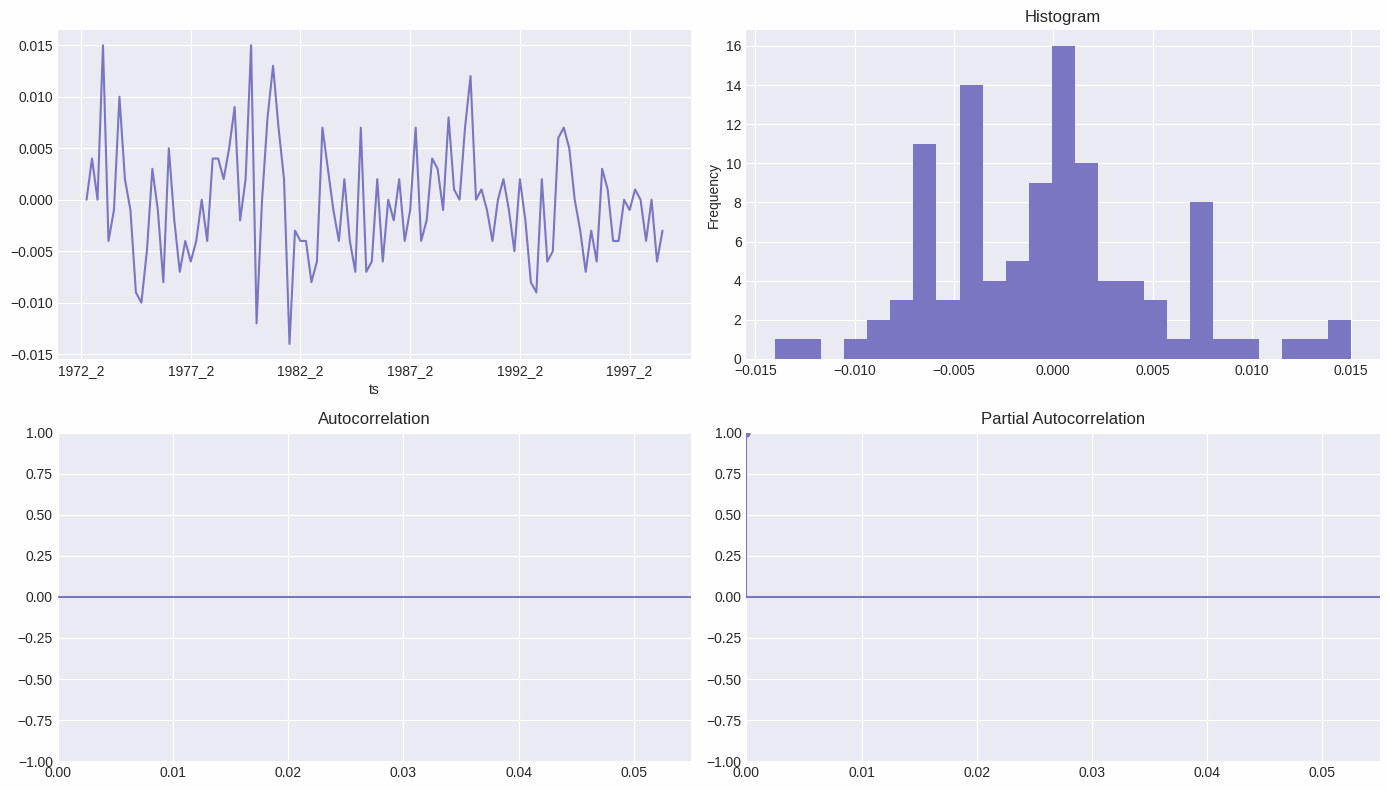

In [ ]:
tsplot(df.delta_R)

#### Optimal AR & MA Orders

In [ ]:
# Alternative model selection method, limited to only searching AR and MA parameters

train_results = sm.tsa.arma_order_select_ic(df.R, ic=['aic', 'bic'], trend='n', max_ar=4, max_ma=4)

print('AIC', train_results.aic_min_order)
print('BIC', train_results.bic_min_order)

NameError: name 'sm' is not defined

In [ ]:
import itertools

p_min = 0
d_min = 0
q_min = 0
p_max = 4
d_max = 0
q_max = 4

ts = df.R

# Initialize a DataFrame to store the results
results_bic = pd.DataFrame(index=['AR{}'.format(i) for i in range(p_min,p_max+1)],
                           columns=['MA{}'.format(i) for i in range(q_min,q_max+1)])

for p,d,q in itertools.product(range(p_min,p_max+1),
                               range(d_min,d_max+1),
                               range(q_min,q_max+1)):
    if p==0 and d==0 and q==0:
        results_bic.loc['AR{}'.format(p), 'MA{}'.format(q)] = np.nan
        continue

    try:
        model = sm.tsa.SARIMAX(ts, order=(p, d, q),
                               #enforce_stationarity=False,
                               #enforce_invertibility=False,
                              )
        results = model.fit()
        results_bic.loc['AR{}'.format(p), 'MA{}'.format(q)] = results.bic
    except:
        continue
results_bic = results_bic[results_bic.columns].astype(float)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/pyth

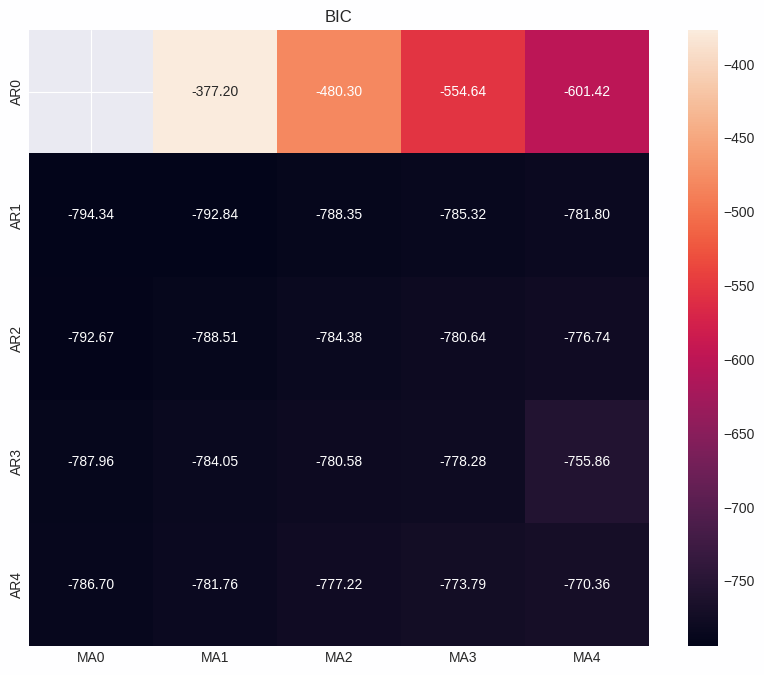

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.heatmap(results_bic,
                 mask=results_bic.isnull(),
                 ax=ax,
                 annot=True,
                 fmt='.2f',
                 );
ax.set_title('BIC');

In [ ]:
# Alternative model selection method, limited to only searching AR and MA parameters

train_results = sm.tsa.arma_order_select_ic(ts, ic=['aic', 'bic'], trend='n', max_ar=4, max_ma=4)

print('AIC', train_results.aic_min_order)
print('BIC', train_results.bic_min_order)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Like

AIC (1, 1)
BIC (1, 0)


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


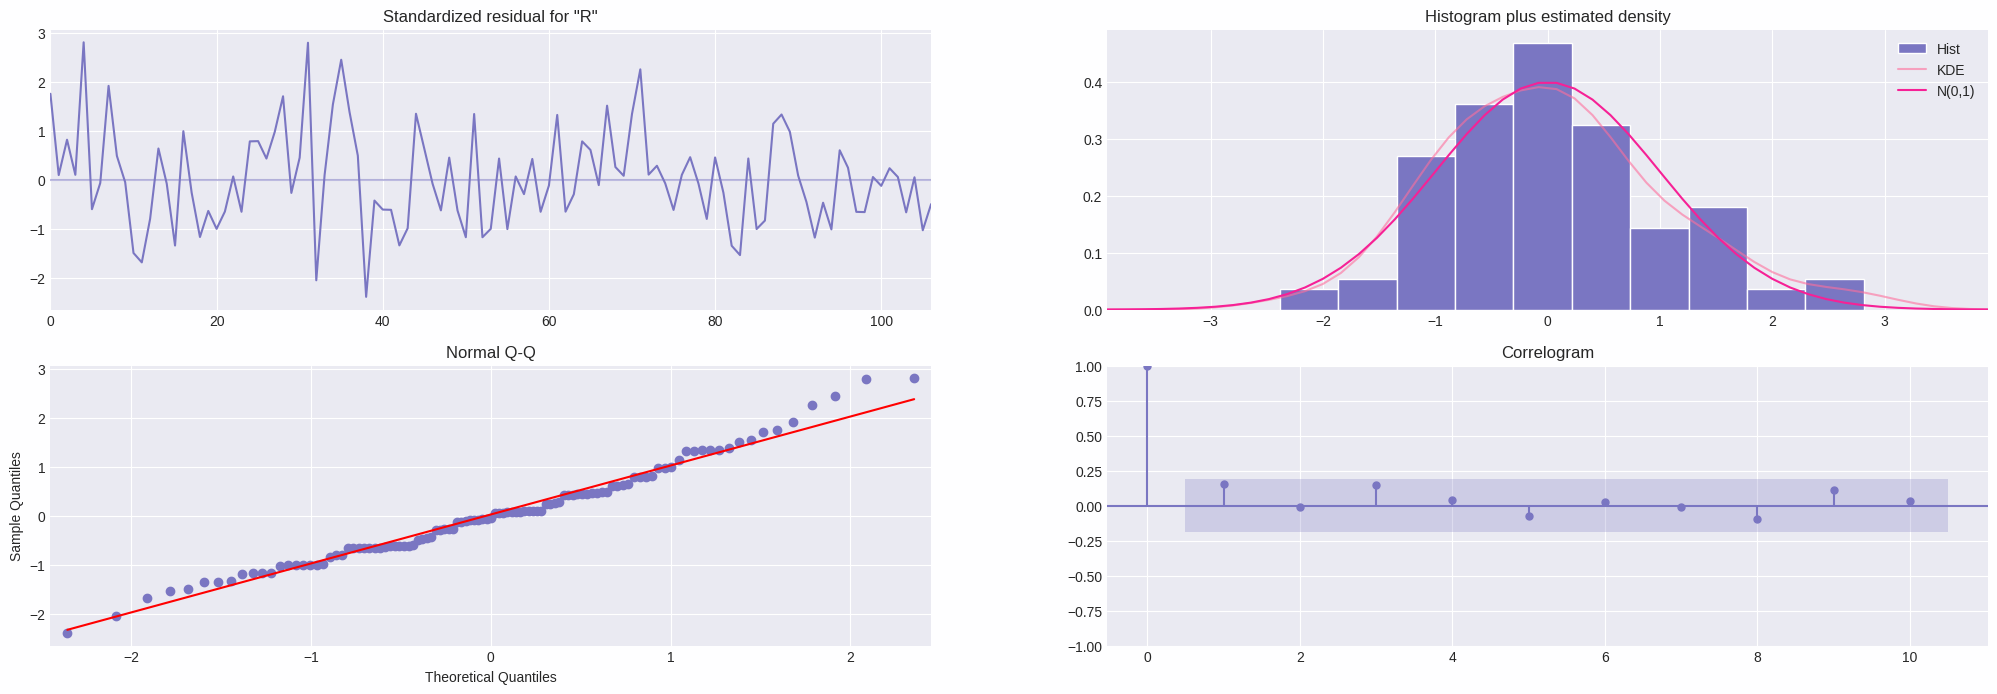

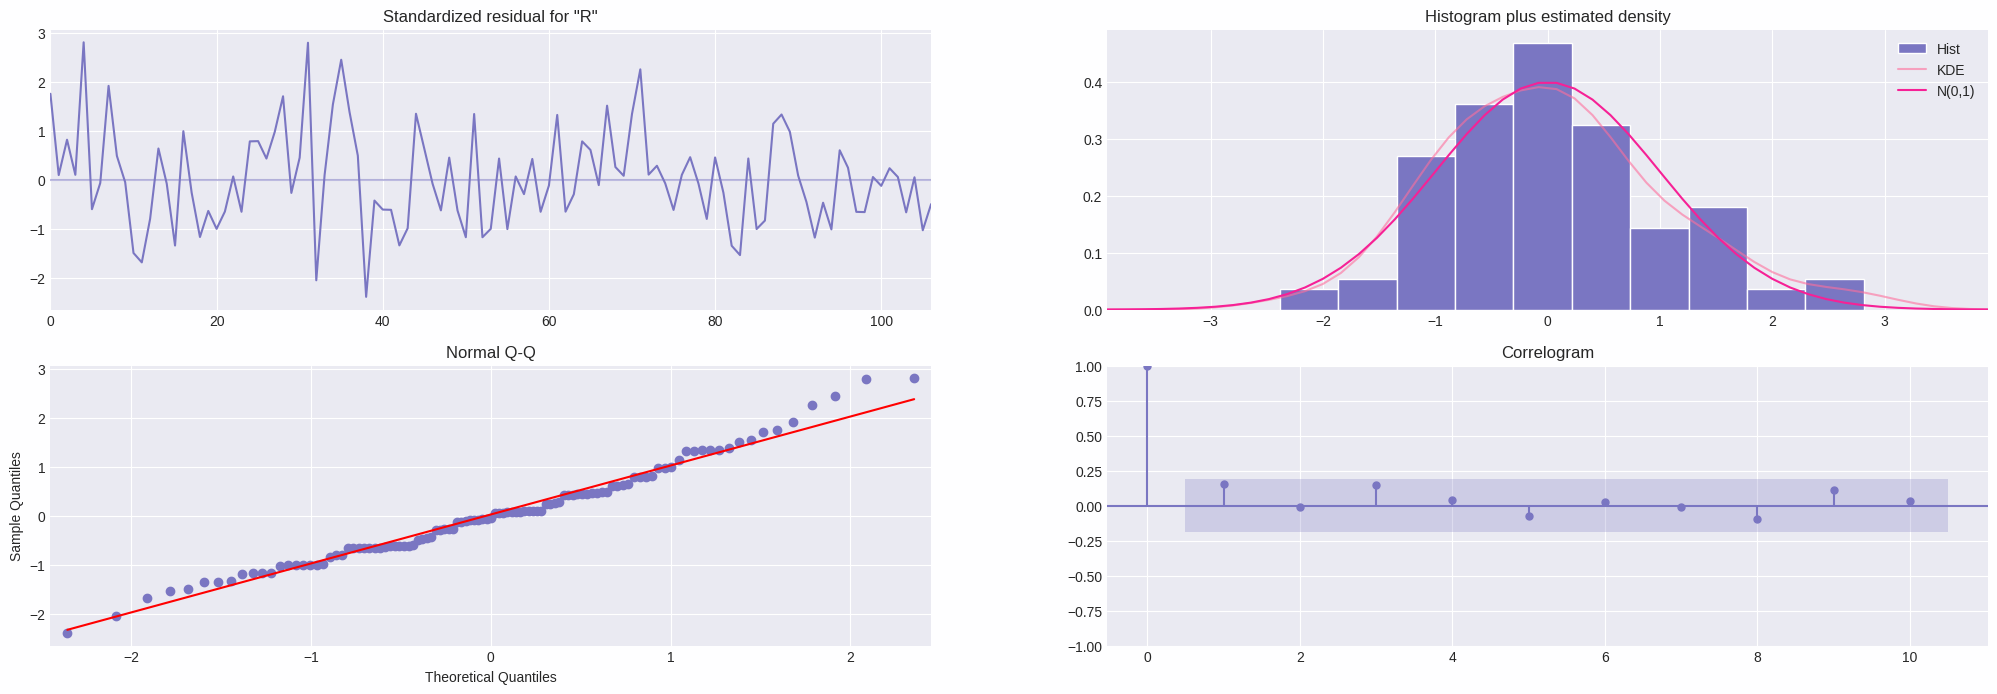

In [ ]:
model_results.plot_diagnostics()